# Part E: Tree-Based Regression Models

## Objectives
1. Implement Decision Tree Regression
2. Control tree complexity using hyperparameters
3. Implement Random Forest Regression
4. Compare single-tree vs ensemble performance


In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('Advanced Regression HousePrice.csv')
df.head()


,property_id,sale_date,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr
0,200001,2014-01-01,2181,6,4,8.1,21,3.8,0,0,4.84,35154898
1,200002,2019-12-01,2383,5,4,5.3,28,10.9,1,1,2.89,26710893
2,200003,2016-10-01,1047,3,3,5.9,7,27.5,0,1,4.04,11216242
3,200004,2013-03-01,1753,4,3,7.0,27,12.1,0,0,3.28,21984310
4,200005,2013-07-01,1728,4,4,10.0,32,1.4,0,1,3.84,25080429


In [2]:
# Basic preprocessing

if 'sale_date' in df.columns:
    df['sale_date'] = pd.to_datetime(df['sale_date'])
    df['sale_year'] = df['sale_date'].dt.year
    df['sale_month'] = df['sale_date'].dt.month
    df.drop('sale_date', axis=1, inplace=True)

target_col = 'house_price_inr'

X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Train Shape:", X_train.shape)
print("Test Shape :", X_test.shape)


Train Shape: (3040, 12)
Test Shape : (760, 12)


## Decision Tree Regression

In [3]:
dt_params = {
    'max_depth':[3,5,10,None],
    'min_samples_split':[2,5,10]
}

dt_grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    dt_params,
    cv=5,
    scoring='r2'
)

dt_grid.fit(X_train, y_train)

best_dt = dt_grid.best_estimator_

print("Best Parameters:", dt_grid.best_params_)


Best Parameters: {'max_depth': 5, 'min_samples_split': 2}


In [4]:
dt_pred = best_dt.predict(X_test)

dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))
dt_mae = mean_absolute_error(y_test, dt_pred)
dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree Results")
print("RMSE:", dt_rmse)
print("MAE :", dt_mae)
print("R²  :", dt_r2)


Decision Tree Results
RMSE: 3063631.2537640957
MAE : 2325303.8928159946
R²  : 0.8834566744111698


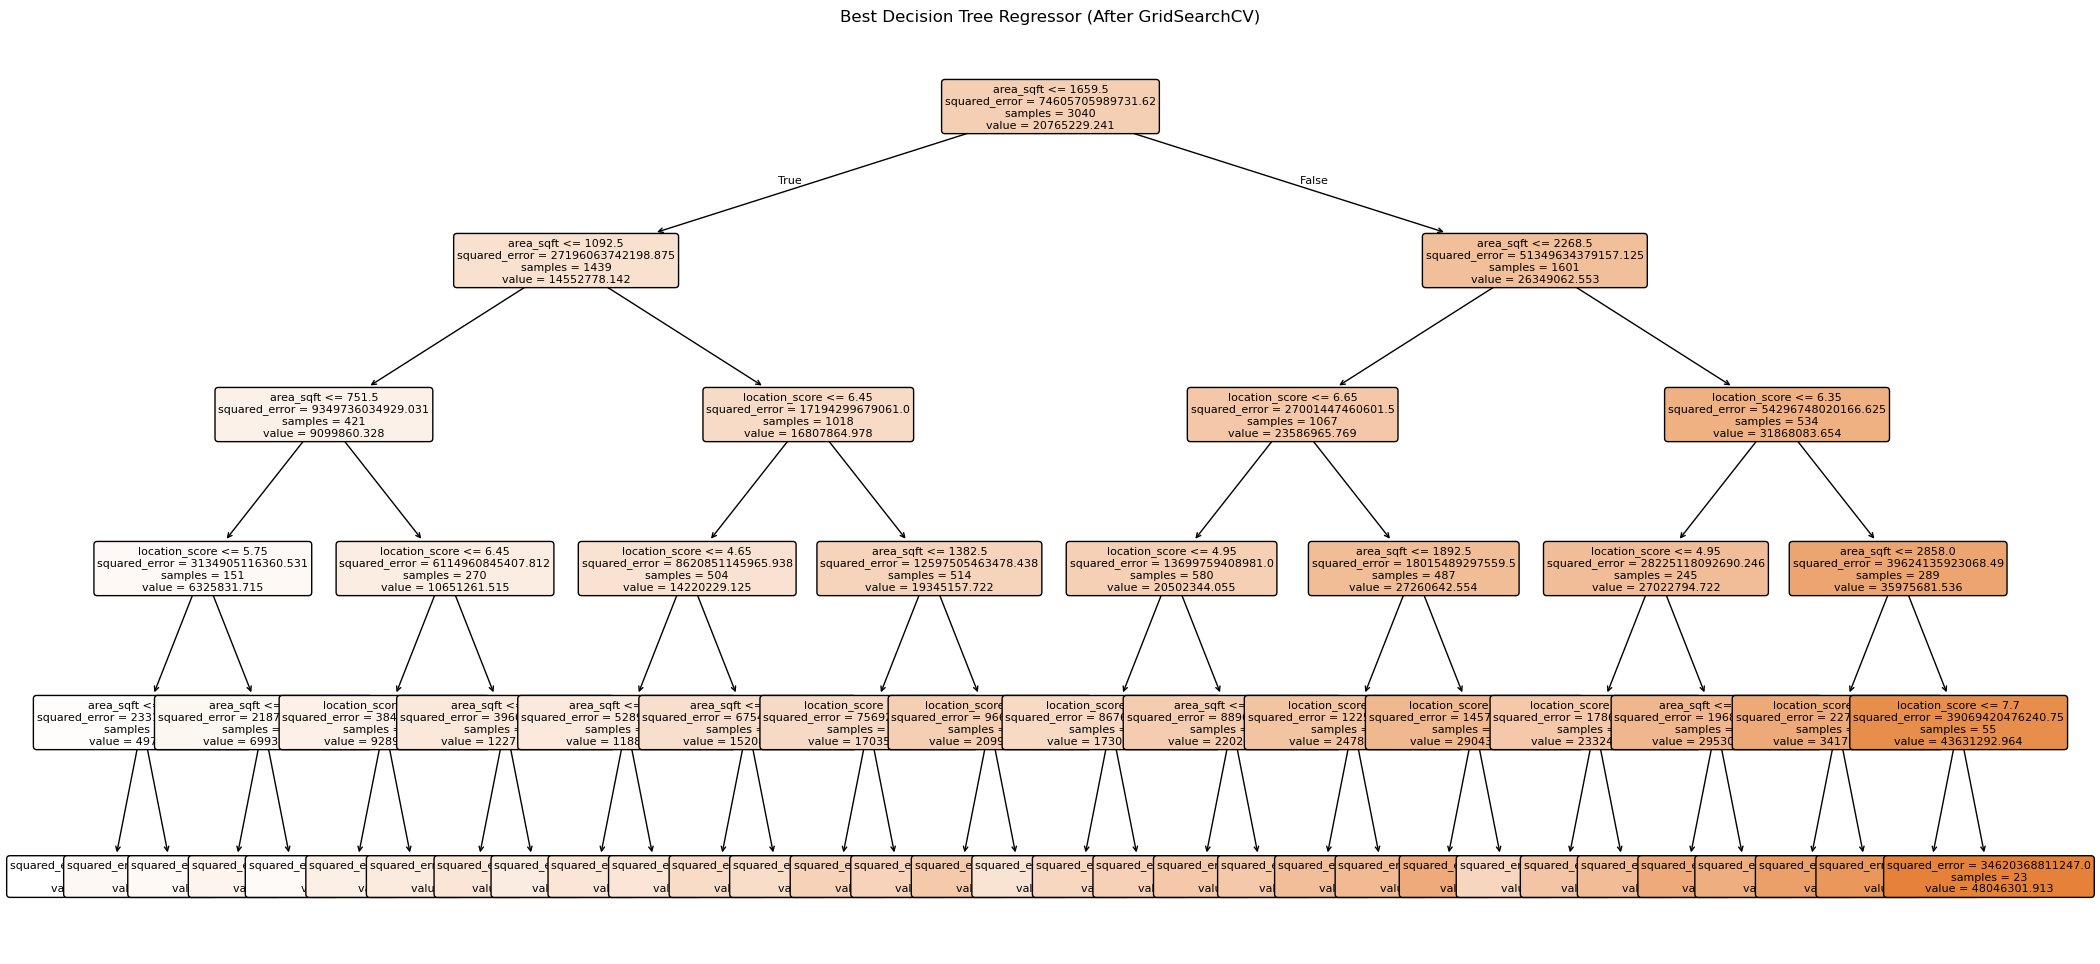

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(25,12))

plot_tree(
    best_dt,
    feature_names=X_train.columns,
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Best Decision Tree Regressor (After GridSearchCV)")
plt.show()

In [18]:
rf_params = {
    'n_estimators':[100,200],
    'max_depth':[5,10,None],
    'min_samples_split':[2,5]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_

print("Best Parameters:", rf_grid.best_params_)


Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}


In [7]:
rf_pred = best_rf.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("RMSE:", rf_rmse)
print("MAE :", rf_mae)
print("R²  :", rf_r2)


Random Forest Results
RMSE: 2411165.356842202
MAE : 1761949.919739011
R²  : 0.9278114340932696


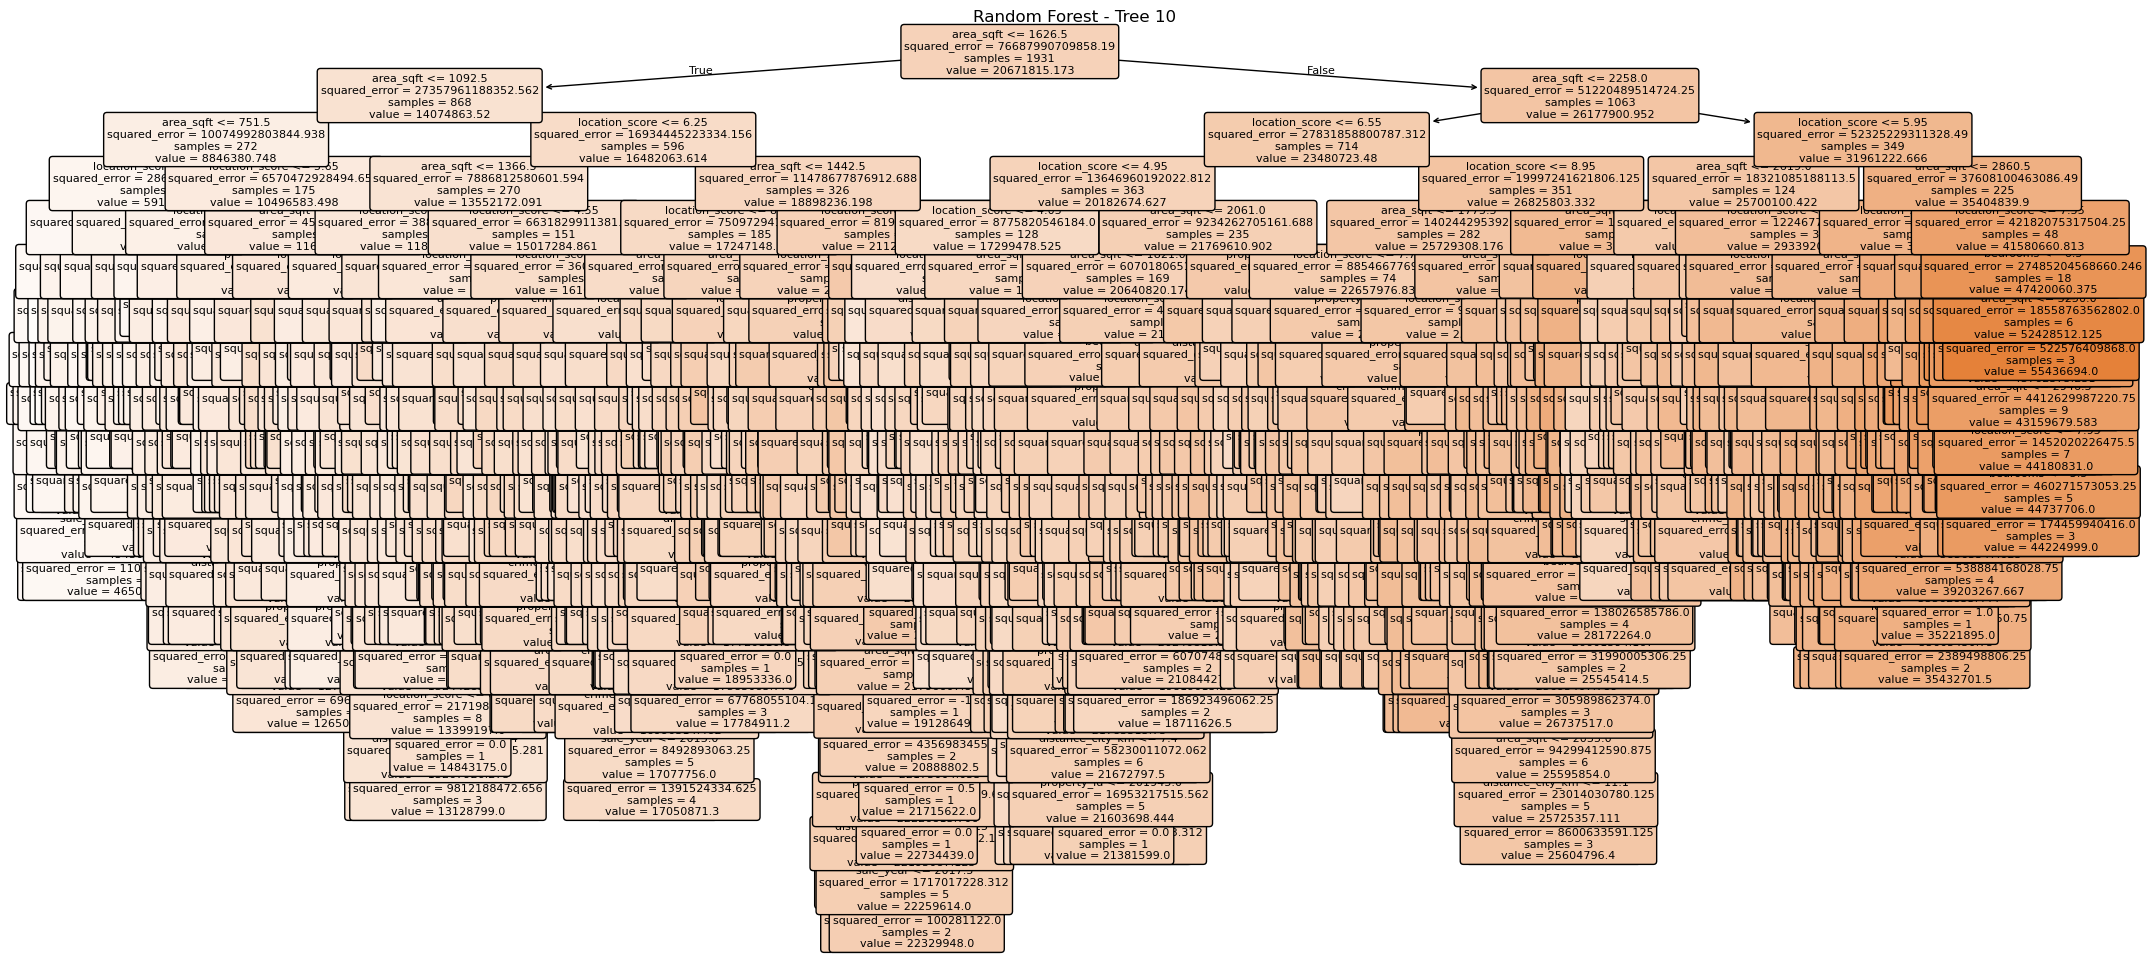

In [22]:
tree_number = 10

plt.figure(figsize=(25,12))

plot_tree(
    best_rf.estimators_[tree_number],
    feature_names=X_train.columns,
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title(f"Random Forest - Tree {tree_number}")
plt.show()

## Model Comparison

In [8]:
comparison = pd.DataFrame({
    'Model':['Decision Tree','Random Forest'],
    'RMSE':[dt_rmse, rf_rmse],
    'MAE':[dt_mae, rf_mae],
    'R2':[dt_r2, rf_r2]
})

comparison.sort_values('R2', ascending=False)


,Model,RMSE,MAE,R2
1,Random Forest,2.411165e+06,1.761950e+06,0.927811
0,Decision Tree,3.063631e+06,2.325304e+06,0.883457


## Feature Importance (Random Forest)

In [9]:
feature_importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':best_rf.feature_importances_
}).sort_values('Importance', ascending=False)

feature_importance.head(10)


,Feature,Importance
1,area_sqft,0.744642
4,location_score,0.205577
5,property_age,0.010741
6,distance_city_km,0.007775
0,property_id,0.007400
9,crime_rate_index,0.007081
10,sale_year,0.005228
11,sale_month,0.004440
2,bedrooms,0.002645
3,bathrooms,0.002583


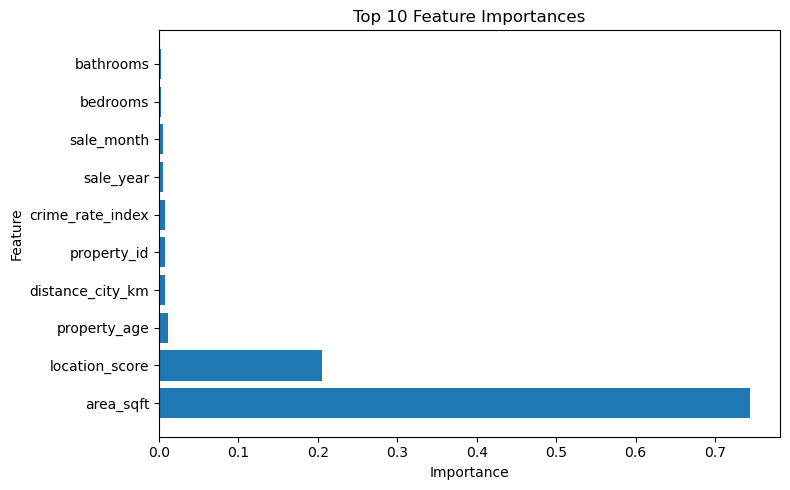

In [10]:
plt.figure(figsize=(8,5))
plt.barh(
    feature_importance['Feature'][:10],
    feature_importance['Importance'][:10]
)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 Feature Importances')
plt.tight_layout()
plt.show()


## Analysis

### Decision Tree
- Easy to interpret.
- Can overfit if tree depth becomes large.
- Sensitive to small changes in data.

### Random Forest
- Ensemble of multiple trees.
- Reduces variance and overfitting.
- Usually achieves better generalization.

### Expected Outcome
Random Forest generally performs better than a single Decision Tree because averaging multiple trees produces more stable predictions.
